To analytically define the ratio X between the area of a circle and the area of a square with length 1 = diameter of circle:

Area of square = 1^2 = 1
radius of circle = diameter / 2 = length of square / 2 = 1 / 2
Area of circle = π * (radius)^2 = π * (1/2)^2 = π / 4

Therefore the ratio X is given by: 
X = Area of circle / Area of square = (π / 4) / 1 = π / 4.

$\hat{X}$ = $\frac{\pi}{4}$ = X

$\hat{X}$ * 4 = π

In [1]:
import numpy as np

# Generate 10,000 random (x, y) pairs uniformly in [0, 1] x [0, 1]
pairs = np.random.uniform(0, 1, size=(10000, 2))
circle_count = 0
for i in range(len(pairs)):
    if (pairs[i][0] - 0.5)**2 + (pairs[i][1] - 0.5)**2 <= (0.5)**2:
        circle_count += 1
X_hat = circle_count / len(pairs)
print(X_hat)

0.7955


In [2]:
pi_hat = X_hat * 4
print(pi_hat)

3.182


In [3]:
x_1 = np.random.uniform(0, 1, size=(10000))
x_2 = x_1 + np.random.uniform(-0.1, 0.1, size=(10000))
pairs2 = np.column_stack((x_1, x_2))
circle_count2 = 0
for i in range(len(pairs2)):
    if (pairs2[i][0] - 0.5)**2 + (pairs2[i][1] - 0.5)**2 <= (0.5)**2:
        circle_count2 += 1
X_hat2 = circle_count2 / len(pairs2)
print(X_hat2)
pi_hat2 = X_hat2 * 4
print(pi_hat2)

0.7012
2.8048


The estimates when we include random noise are lower than the estimates without noise. This is due to some points now falling outside the square due to the added noise, which reduces the number of points that fall within the circle, thus lowering the estimate of π.

## Exercise 2

This is a control problem, because we want to find the optimal policy that maximizes the expected reward. The epsilon greedy algorithm for MABs specifically does this by balancing exploration and exploitation, allowing us to find the best action while still exploring other options to ensure we don't miss out on potentially better rewards.

The expected reward of pulling an arm corresponds to a action-value function, which estimates the expected reward of doing an action given a state.

# 2  
A trajectory for a MAB would correspond to the seqence of actions taken and rewards recieved over a full run of the algorithm.

# 3
A collection of trajectories would correspond to a collection of runs of the algorithm. E.g. multiple experiments.

# 4
All the MAB algorithms we discussed corresponds to MC control, as each trajectory is generated by an updating policy.

# 5
MC prediction would be equivalent to estimating the expected reward of pulling an arm by averaging the rewards received from pulling that arm over multiple trajectories. This would give us an estimate of the action-value function for that arm, which is what MC prediction aims to do.

# 6

epsilon is a hyperparameter that controls how often we select a random lever in the MAB, and equivalently how often we select a random action in the MC control problem.

# 7
You lose information about the states of the environment as the MAB problem is only a single state problem.







## Exercise 3

# 1
E[R] = 0 * 0.35 + 5 * 0.3 + 10 * 0.25 + 20 * 0.1 = 4.25

E[S] = 0 * 0.3 + 5 * 0.35 + 10 * 0.3 + 20 * 0.05 = 4.25



In [4]:
# 3.2

def slot_machine_R():
    return np.random.choice([0, 5, 10, 20], p=[0.35, 0.3, 0.25, 0.1])

def slot_machine_S():
    return np.random.choice([0, 5, 10, 20], p=[0.3, 0.35, 0.3, 0.05])

# 3.3
rewards_S = []
for i in range(10000):
    rewards_S.append(slot_machine_S())
print("Expected reward for slot machine S:", np.mean(rewards_S))


Expected reward for slot machine S: 5.798


In [5]:
rho = {0: 0.35 / 0.3, 5: 0.3 / 0.35, 10: 0.25 / 0.3, 20: 0.1 / 0.05}  # rho[x] = P_R(x) / P_S(x)
rewards_R = []
for reward in rewards_S:
    rewards_R.append(reward * rho[reward])

print("Expected reward for slot machine R:", np.mean(rewards_R))

Expected reward for slot machine R: 6.042928571428573


In [6]:
# 3.4 - S' with uniform distribution
def slot_machine_S_prime():
    return np.random.choice([0, 5, 10, 20], p=[0.25, 0.25, 0.25, 0.25])

rewards_S_prime = [slot_machine_S_prime() for _ in range(10000)]
print("Estimated E[S']:", np.mean(rewards_S_prime))

rho_prime = {0: 0.35 / 0.25, 5: 0.3 / 0.25, 10: 0.25 / 0.25, 20: 0.1 / 0.25}
weighted_rewards_R_from_S_prime = [reward * rho_prime[reward] for reward in rewards_S_prime]

print("Estimated E[R] via importance sampling from S':", np.mean(weighted_rewards_R_from_S_prime))

Estimated E[S']: 8.764
Estimated E[R] via importance sampling from S': 6.045


In [7]:
# 3.5 - S'' with highly skewed middle outcomes
def slot_machine_S_double_prime():
    return np.random.choice([0, 5, 10, 20], p=[0.001, 0.499, 0.499, 0.001])

rewards_S_double_prime = [slot_machine_S_double_prime() for _ in range(10000)]
print("Estimated E[S'']:", np.mean(rewards_S_double_prime))

rho_double_prime = {0: 0.35 / 0.001, 5: 0.3 / 0.499, 10: 0.25 / 0.499, 20: 0.1 / 0.001}
weighted_rewards_R_from_S_double_prime = [reward * rho_double_prime[reward] for reward in rewards_S_double_prime]

print("Estimated E[R] via importance sampling from S'':", np.mean(weighted_rewards_R_from_S_double_prime))

# Optional diagnostics for comparison
print("Var of weighted rewards (S):", np.var(rewards_R))
print("Var of weighted rewards (S'):", np.var(weighted_rewards_R_from_S_prime))
print("Var of weighted rewards (S''):", np.var(weighted_rewards_R_from_S_double_prime))

Estimated E[S'']: 7.4585
Estimated E[R] via importance sampling from S'': 4.587675350701403
Var of weighted rewards (S): 71.14258911054421
Var of weighted rewards (S'): 13.741575
Var of weighted rewards (S''): 1195.877966102545


### 3.6 - Why the results differ
All three importance-sampling estimates target the same quantity $E[R]$, so with many samples they should be close to the true value.

The main difference is **variance**, caused by how different the behavior distribution is from $R$ (the size/spread of $\rho=\frac{P_R}{P_{behavior}}$):
- For $S$ and especially $S'$, probabilities overlap reasonably well with $R$, so weights are moderate and estimates are stable.
- For $S''$, rare events under $S''$ (0 and 20) get very large weights ($\rho(0)=350$, $\rho(20)=100$), which can create large fluctuations when those outcomes appear.

So the estimates can differ in finite samples because importance sampling is unbiased in expectation but can have very high variance when behavior and target policies/distributions are very different.

## Exercise 5

This section solves 5.1-5.6 from `P3.pdf` using the fixed dataset `trajectories.pickle`.


In [2]:
from pathlib import Path
import pickle
import numpy as np

pickle_path = Path('trajectories.pickle')
with pickle_path.open('rb') as f:
    trajectories = pickle.load(f)

print(f'Loaded {len(trajectories)} trajectories from {pickle_path}')
print(f'Example trajectory length: {len(trajectories[0])}')
print('Example step format:', trajectories[0][0])


Loaded 1000 trajectories from trajectories.pickle


Estimated values for 2924 states


Estimated values for 2924 states


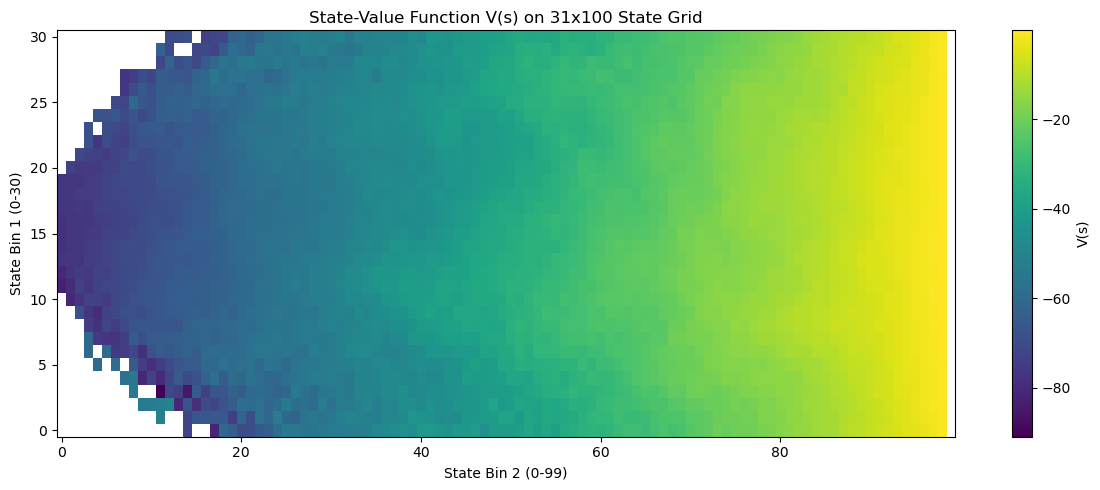

In [3]:
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

def mc_first_visit_v_q(trajectories, gamma=1.0):
    """
    First-visit Monte Carlo evaluation for V_pi(s) and Q_pi(s,a)
    from fixed trajectories generated by policy pi.
    Each step is assumed to be: (s, a, r, s_next).
    """
    returns_v = defaultdict(list)
    returns_q = defaultdict(list)

    for traj in trajectories:
        G = 0.0
        visited_s = set()
        visited_sa = set()

        for s, a, r, s_next in reversed(traj):
            s = (int(s[0]), int(s[1]))
            a = int(a)
            r = float(r)

            G = r + gamma * G

            if s not in visited_s:
                returns_v[s].append(G)
                visited_s.add(s)

            if (s, a) not in visited_sa:
                returns_q[(s, a)].append(G)
                visited_sa.add((s, a))

    V = {s: float(np.mean(gs)) for s, gs in returns_v.items()}
    Q = {(s, a): float(np.mean(gs)) for (s, a), gs in returns_q.items()}
    return V, Q, returns_v, returns_q

V, Q, returns_v, returns_q = mc_first_visit_v_q(trajectories, gamma=1.0)
print(f'Estimated V for {len(V)} states')
print(f'Estimated Q for {len(Q)} state-action pairs')

# 5.3 Plot V_pi(s) on the 31x100 state grid
value_grid = np.full((31, 100), np.nan, dtype=float)
for (x, y), v in V.items():
    if 0 <= x < 31 and 0 <= y < 100:
        value_grid[x, y] = v

plt.figure(figsize=(12, 4.8))
im = plt.imshow(value_grid, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(im, label='V_pi(s)')
plt.title('Exercise 5.3: Monte Carlo State-Value Function')
plt.xlabel('y')
plt.ylabel('x')
plt.tight_layout()
plt.show()

# Coverage/usefulness diagnostics (used in 5.5/5.6 discussion)
state_action_count = Counter()
for traj in trajectories:
    for s, a, r, s_next in traj:
        s = (int(s[0]), int(s[1]))
        a = int(a)
        state_action_count[(s, a)] += 1

actions_by_state = defaultdict(set)
for (s, a) in Q:
    actions_by_state[s].add(a)

greedy_policy_observed = {
    s: max(actions, key=lambda a: Q[(s, a)])
    for s, actions in actions_by_state.items()
}

behavior_policy_empirical = {}
tmp = defaultdict(Counter)
for (s, a), c in state_action_count.items():
    tmp[s][a] = c
for s, cnt in tmp.items():
    behavior_policy_empirical[s] = cnt.most_common(1)[0][0]

changed_states = sum(
    1 for s in greedy_policy_observed
    if greedy_policy_observed[s] != behavior_policy_empirical.get(s)
)

print(f'States with >= 2 observed actions: {sum(len(v) >= 2 for v in actions_by_state.values())}/{len(actions_by_state)}')
print(f'States where greedy(Q) differs from empirical behavior action: {changed_states}/{len(greedy_policy_observed)}')
print(f'(s,a) pairs with <=3 first-visit samples: {sum(len(v) <= 3 for v in returns_q.values())}/{len(returns_q)}')


### 5.4 MC improvement

You can perform **limited MC improvement** on the fixed dataset by making a greedy policy over the observed actions:
$$\pi_{new}(s) = \arg\max_{a \in A_{obs}(s)} Q_\pi(s,a).$$

However, this does **not** guarantee optimality because:
- Unobserved actions cannot be evaluated from the static dataset.
- Many $(s,a)$ estimates have few samples and high variance.
- You cannot roll out $\pi_{new}$ to evaluate/improve it iteratively without new interaction.


### 5.5 and 5.6 Discussion

- Trajectories are **not equally useful**. Early/high-reward and frequently visited regions reduce variance more. Rare $(s,a)$ pairs contribute noisy estimates.
- Therefore MC evaluation quality depends strongly on coverage of state-action space.
- With only fixed trajectories from one behavior policy, full MC control is generally **not feasible**. You can do off-policy estimation/improvement only where behavior has enough support.
- So for 5.6: a complete claim of optimal control is not justified from this static dataset alone.


In [ ]:
import gymnasium as gym

import mountain



# Load the first version of the mountain environment

env = gym.make("mountain/GridWorld-v1")

obs, info = env.reset()

obs, info


## 5.7 Choose a starting policy (for `mountain/GridWorld-v1`)
Starting policy: **forward-biased centerline policy**.

- `0=forward`, `1=left`, `2=forward-left`, `3=right`, `4=forward-right`.
- If `x<14`: choose `4`; if `x>16`: choose `2`; otherwise choose `0`.
- This keeps forward progress while steering back toward the center row.


In [ ]:
def heuristic_start_action(state):
    x, y = state
    if x < 14:
        return 4
    if x > 16:
        return 2
    return 0



## 5.8 Perform MC control on `mountain/GridWorld-v1`
On-policy first-visit MC control with epsilon-greedy improvement.


In [ ]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
import mountain

env = gym.make('mountain/GridWorld-v1')

def obs_to_state(obs):
    p = obs['agent']['pos']
    return (int(p[0]), int(p[1]))

def eps_greedy(Q, s, nA, eps=0.10):
    if np.random.rand() < eps:
        return np.random.randint(nA)
    qs = np.array([Q[(s,a)] for a in range(nA)], dtype=float)
    if np.allclose(qs, qs[0]):
        return heuristic_start_action(s)
    return int(np.random.choice(np.flatnonzero(qs == qs.max())))

def run_episode(Q, eps=0.10, gamma=1.0):
    obs, _ = env.reset()
    s = obs_to_state(obs)
    traj = []
    done = False
    while not done:
        a = eps_greedy(Q, s, env.action_space.n, eps)
        obs2, r, term, trunc, _ = env.step(a)
        traj.append((s,a,float(r)))
        s = obs_to_state(obs2)
        done = term or trunc
    return traj

def mc_control(episodes=3000, eps=0.10, gamma=1.0):
    Q = defaultdict(float)
    returns = defaultdict(list)
    for ep in range(episodes):
        traj = run_episode(Q, eps, gamma)
        G = 0.0
        seen = set()
        for t in reversed(range(len(traj))):
            s,a,r = traj[t]
            G = r + gamma*G
            if (s,a) not in seen:
                returns[(s,a)].append(G)
                Q[(s,a)] = float(np.mean(returns[(s,a)]))
                seen.add((s,a))
        if (ep+1) % 500 == 0:
            print(f'Episode {ep+1}')
    return Q

Q_control = mc_control(episodes=3000, eps=0.10, gamma=1.0)
print('Trained Q entries:', len(Q_control))

